In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

In [3]:
# --- 1. CONFIGURATION ---
TRAIN_PATH = 'OneDrive_1_09-04-2026/x_train/'
TEST_PATH = 'OneDrive_1_09-04-2026/x_test/'
Y_TRAIN_FILE = 'OneDrive_1_09-04-2026/y_train_v2.csv'


In [4]:
# --- 2. CHARGEMENT DES LABELS ---
labels_df = pd.read_csv(Y_TRAIN_FILE)

def load_images_from_folder(folder, start_idx, end_idx, is_train=True):
    images = []
    labels = []
    total = end_idx - start_idx + 1

    print(f"--- Chargement de {total} images dans {folder} ---")

    for count, i in enumerate(range(start_idx, end_idx + 1)):
        img_name = f"img_{i}.png"
        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)

            if is_train:
                target = labels_df.loc[labels_df['id'] == (i - 1), 'target'].values[0]
                labels.append(target)

        if (count + 1) % 500 == 0:
            print(f"Progression : {count + 1} / {total} images chargées...")

    return np.array(images), np.array(labels)


In [5]:
# Chargement Train & Test
X_train, y_train = load_images_from_folder(TRAIN_PATH, 1, 9227, is_train=True)
X_kaggle, _ = load_images_from_folder(TEST_PATH, 9228, 13182, is_train=False)

IMG_H, IMG_W, IMG_C = X_train[0].shape

# Normalisation
X_train = X_train.astype('float32') / 255.0
X_kaggle = X_kaggle.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, num_classes=4)

--- Chargement de 9227 images dans OneDrive_1_09-04-2026/x_train/ ---
Progression : 500 / 9227 images chargées...
Progression : 1000 / 9227 images chargées...
Progression : 1500 / 9227 images chargées...
Progression : 2000 / 9227 images chargées...
Progression : 2500 / 9227 images chargées...
Progression : 3000 / 9227 images chargées...
Progression : 3500 / 9227 images chargées...
Progression : 4000 / 9227 images chargées...
Progression : 4500 / 9227 images chargées...
Progression : 5000 / 9227 images chargées...
Progression : 5500 / 9227 images chargées...
Progression : 6000 / 9227 images chargées...
Progression : 6500 / 9227 images chargées...
Progression : 7000 / 9227 images chargées...
Progression : 7500 / 9227 images chargées...
Progression : 8000 / 9227 images chargées...
Progression : 8500 / 9227 images chargées...
Progression : 9000 / 9227 images chargées...
--- Chargement de 3955 images dans OneDrive_1_09-04-2026/x_test/ ---
Progression : 500 / 3955 images chargées...
Progress

In [6]:
# --- 3. ARCHITECTURE DU MODÈLE (CNN) ---
model = Sequential([
    Input(shape=(IMG_H, IMG_W, IMG_C)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 43, 49, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6336)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       811,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 831,044 (3.17 MB)

 Trainable params: 831,044 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
# --- 4. ENTRAÎNEMENT ---
print("\nDébut de l'entraînement...")
history = model.fit(X_train, y_train_cat, epochs=30, batch_size=32)


Début de l'entraînement...
Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6691 - loss: 0.7879
Epoch 2/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8133 - loss: 0.4660
Epoch 3/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8568 - loss: 0.3509
Epoch 4/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8828 - loss: 0.3014
Epoch 5/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8967 - loss: 0.2653
Epoch 6/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9082 - loss: 0.2329
Epoch 7/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9144 - loss: 0.2180
Epoch 8/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9265 - loss: 0.1872
Epoch 9/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9310 - loss: 0.1746
Epoch 10/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9376 - loss: 0.1614
Epoch 11/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9379 - loss: 0.1559
Epoch 12/30
289/289 ━━━

In [8]:
# --- 5. PRÉDICTION & KAGGLE SUBMISSION ---
print("\nGénération des prédictions pour Kaggle...")
preds = model.predict(X_kaggle)
final_preds = np.argmax(preds, axis=1)

submission = pd.DataFrame({
    'id': np.arange(9227, 9227 + len(final_preds)),
    'target': final_preds
})


Génération des prédictions pour Kaggle...
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


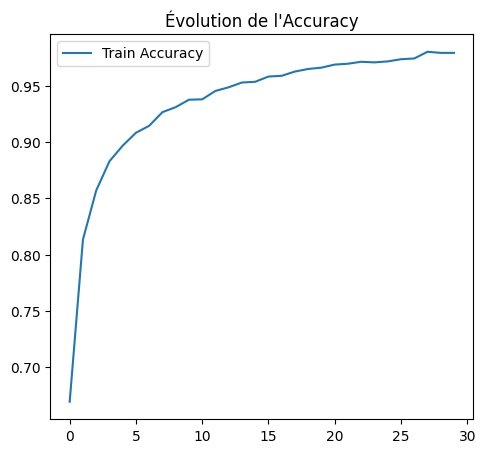

In [9]:
# --- 6. COURBES D'ENTRAÎNEMENT ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title("Évolution de l'Accuracy")
plt.legend()


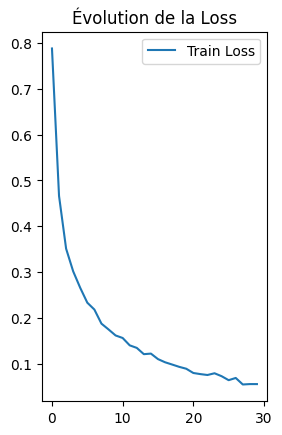

In [10]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Évolution de la Loss')
plt.legend()
plt.show()